# CVRP — Genetic Algorithm Analysis
## Dataset: CVRPLIB X-n101-k25 (Uchoa et al., 2014)

| Property | Value |
|---|---|
| Customers | **100** |
| Depot | Node 1  (365, 689) |
| Vehicle capacity Q | **206** |
| Distance metric | EUC_2D |
| Known optimal cost | **27 591** |
| Optimal vehicle count | 26 |

**GA Architecture**

| Component | Choice | Rationale |
|---|---|---|
| Chromosome | Permutation of 100 customers | Standard VRP encoding |
| Decoder | Greedy split-tour | O(n), always capacity-feasible |
| Selection | Tournament (k = 3) | Controlled pressure, preserves diversity |
| Crossover | Ordered Crossover (OX) | Preserves relative order in permutations |
| Mutation | Swap OR 2-opt reversal (50/50) | Swap explores; 2-opt exploits route structure |
| Elitism | Top 5 chromosomes | Prevents regression of best solution |


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Imports & Style
# ═══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import seaborn as sns
import time, math, random, warnings

warnings.filterwarnings('ignore')

# ── Colour palette ────────────────────────────────────────────
DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
BORDER   = '#30363d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
C_RED    = '#ff7b72'
C_BLUE   = '#79c0ff'
C_GREEN  = '#56d364'
C_ORANGE = '#ffa657'
C_PURPLE = '#d2a8ff'
C_GOLD   = '#f0e040'

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,   'axes.facecolor'  : PANEL_BG,
    'axes.edgecolor'   : BORDER,    'axes.labelcolor' : TEXT,
    'axes.titlesize'   : 13,        'axes.titleweight': 'bold',
    'axes.titlecolor'  : TEXT,      'text.color'      : TEXT,
    'xtick.color'      : MUTED,     'ytick.color'     : MUTED,
    'grid.color'       : '#21262d', 'legend.facecolor': '#21262d',
    'legend.edgecolor' : BORDER,    'legend.fontsize' : 9,
    'font.family'      : 'monospace','font.size'      : 11,
    'lines.linewidth'  : 1.8,
})

sol_file_path = "data/X-n101-k25.sol"

OPTIMAL_ROUTES = []
OPTIMAL_COST = 0

with open(sol_file_path, 'r') as file:
    for line in file:
        line = line.strip()
        if line.startswith("Route"):
            # Split the line by ":" to get the string of nodes
            # Example: "Route #1: 31 46 35" -> " 31 46 35"
            nodes_str = line.split(':')[1]
            
            # Read each node, convert to integer, and add +1
            route = [int(node) + 1 for node in nodes_str.split()]
            OPTIMAL_ROUTES.append(route)
            
        elif line.startswith("Cost"):
            # Extract the cost value
            # Example: "Cost 27591" -> "27591"
            OPTIMAL_COST = int(line.split()[1])

# Verify the results
print(f"OPTIMAL_ROUTES = {OPTIMAL_ROUTES}")
print(f'Imports OK.  Optimal cost = {OPTIMAL_COST:,}  |  Optimal routes = {len(OPTIMAL_ROUTES)}')



OPTIMAL_ROUTES = [[32, 47, 36], [16, 23, 42, 21], [2, 71, 55], [93, 10, 87], [69, 91, 85, 67], [77, 56, 17, 70], [5, 14, 75], [59, 13, 6], [19, 11, 40], [26, 66, 79, 43, 29], [8, 3, 46, 44, 30, 37, 73, 58], [88, 38, 7, 50, 15], [4, 78, 64], [45, 68, 89, 41], [83, 61, 60], [9, 18], [35, 65, 97, 49, 27, 48, 39], [81, 95, 57, 22], [72, 63, 100, 99, 90], [101, 62, 24], [20, 98, 28], [82, 52, 84], [51, 92, 53], [31, 86, 12, 80], [76, 94], [25, 96, 74, 54, 34, 33]]
Imports OK.  Optimal cost = 27,591  |  Optimal routes = 26


In [6]:
# ═══════════════════════════════════════════════════════════════
# Load Dataset
# ═══════════════════════════════════════════════════════════════
def load_vrp(filename):
    coords, demands, capacity = {}, {}, 0
    with open(filename) as f:
        section = None
        for line in f:
            line = line.strip()
            if   'CAPACITY'          in line: capacity = int(line.split(':')[-1])
            elif 'NODE_COORD_SECTION' in line: section = 'coords'
            elif 'DEMAND_SECTION'     in line: section = 'demands'
            elif 'DEPOT_SECTION'      in line or 'EOF' in line: section = None
            elif section == 'coords':
                p = line.split()
                if len(p) == 3: coords[int(p[0])]  = (float(p[1]), float(p[2]))
            elif section == 'demands':
                p = line.split()
                if len(p) == 2: demands[int(p[0])] = int(p[1])
    return coords, demands, capacity

coords, demands, CAPACITY = load_vrp('data/X-n101-k25.vrp')
DEPOT     = 1
nodes     = sorted(coords.keys())
customers = [n for n in nodes if n != DEPOT]   # 100 customers, nodes 2–101

# EUC_2D (CVRPLIB standard)
def euc2d(i, j):
    xi, yi = coords[i]; xj, yj = coords[j]
    return math.floor(math.sqrt((xi-xj)**2 + (yi-yj)**2) + 0.5)

dist = {(i,j): euc2d(i,j) for i in nodes for j in nodes}

def route_cost(route):
    d = dist[DEPOT, route[0]]
    for k in range(len(route)-1): d += dist[route[k], route[k+1]]
    return d + dist[route[-1], DEPOT]

# Verify optimal cost
verified = sum(route_cost(r) for r in OPTIMAL_ROUTES)
assert verified == OPTIMAL_COST, f'Mismatch: got {verified}'

total_demand = sum(demands[c] for c in customers)
print(f'Customers     : {len(customers)}')
print(f'Capacity (Q)  : {CAPACITY}')
print(f'Total demand  : {total_demand}  →  min vehicles = {math.ceil(total_demand/CAPACITY)}')
print(f'Demand range  : {min(demands[c] for c in customers)} – {max(demands[c] for c in customers)}')
print(f'Optimal cost  : {verified:,}  ✓  (matches CVRPLIB benchmark)')


Customers     : 100
Capacity (Q)  : 206
Total demand  : 5147  →  min vehicles = 25
Demand range  : 1 – 100
Optimal cost  : 27,591  ✓  (matches CVRPLIB benchmark)


## Dataset Exploration

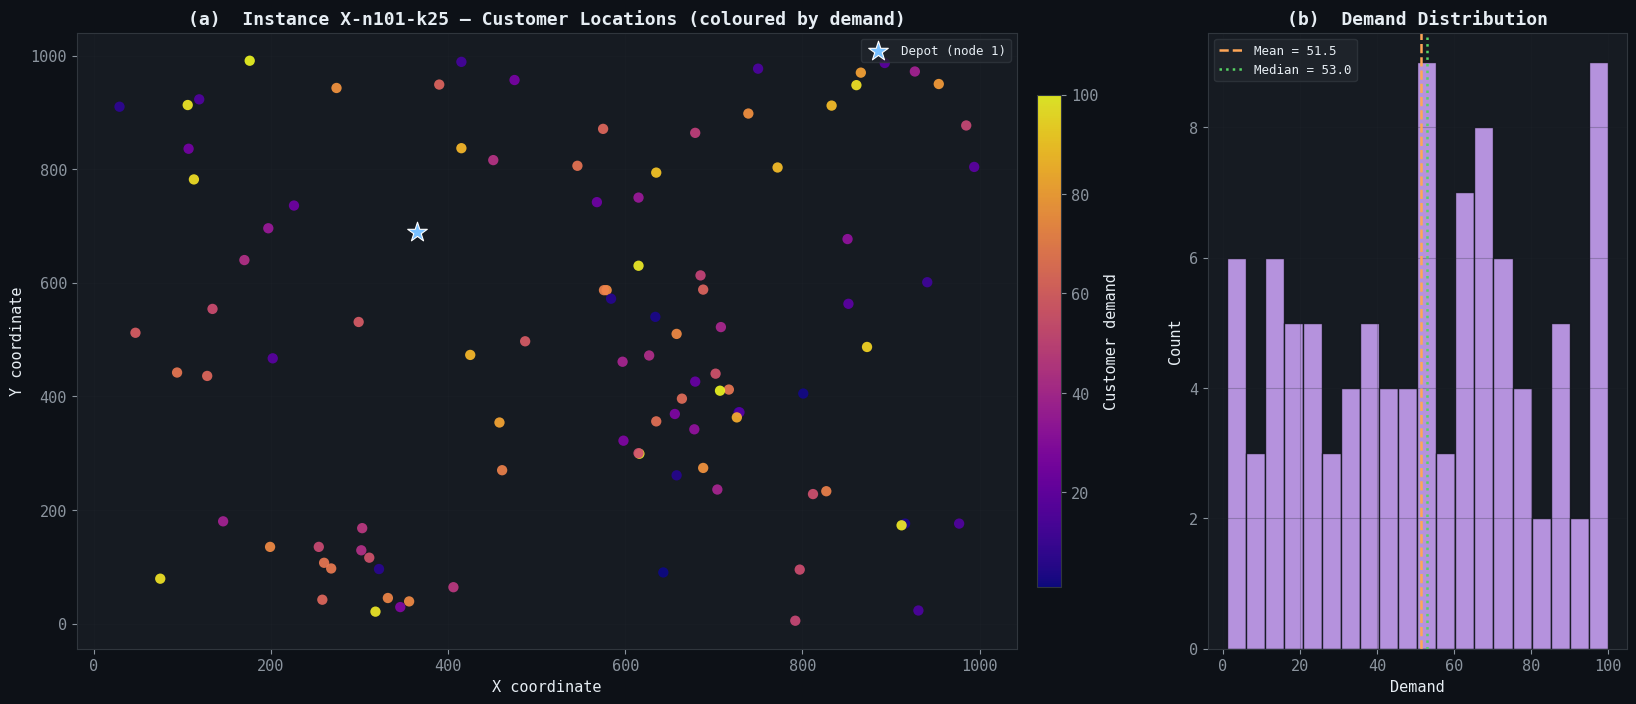

Fig 1 saved.


In [7]:
# ═══════════════════════════════════════════════════════════════
# Dataset Visualization
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 8), facecolor=DARK_BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── (a) Scatter map ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
cx = [coords[c][0] for c in customers]
cy = [coords[c][1] for c in customers]
sc = ax1.scatter(cx, cy, c=[demands[c] for c in customers],
                 cmap='plasma', s=55, zorder=3, alpha=0.9, edgecolors='none')
ax1.scatter(*coords[DEPOT], c=C_BLUE, s=220, marker='*', zorder=6,
            edgecolors='white', linewidths=0.8, label='Depot (node 1)')
cb = plt.colorbar(sc, ax=ax1, fraction=0.025, pad=0.02)
cb.set_label('Customer demand', color=TEXT); cb.ax.yaxis.set_tick_params(color=MUTED)
ax1.set_title('(a)  Instance X-n101-k25 — Customer Locations (coloured by demand)')
ax1.set_xlabel('X coordinate'); ax1.set_ylabel('Y coordinate')
ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.25)

# ── (b) Demand histogram ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
dem_vals = [demands[c] for c in customers]
ax2.hist(dem_vals, bins=20, color=C_PURPLE, edgecolor=DARK_BG, alpha=0.85)
ax2.axvline(np.mean(dem_vals), color=C_ORANGE, linestyle='--', linewidth=1.8,
            label=f'Mean = {np.mean(dem_vals):.1f}')
ax2.axvline(np.median(dem_vals), color=C_GREEN, linestyle=':', linewidth=1.8,
            label=f'Median = {np.median(dem_vals):.1f}')
ax2.set_title('(b)  Demand Distribution')
ax2.set_xlabel('Demand'); ax2.set_ylabel('Count')
ax2.legend(); ax2.grid(True, alpha=0.25)

plt.savefig('output/GA/fig1_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved.')


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Known Optimal Solution — Route Map
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 10), facecolor=DARK_BG)
cmap_opt = cm.get_cmap('hsv', len(OPTIMAL_ROUTES))
patches  = []

for ri, route in enumerate(OPTIMAL_ROUTES):
    col  = cmap_opt(ri)
    full = [DEPOT] + route + [DEPOT]
    xs   = [coords[n][0] for n in full]
    ys   = [coords[n][1] for n in full]
    ax.plot(xs, ys, '-o', color=col, linewidth=1.1, markersize=3.8, alpha=0.85)
    load = sum(demands[n] for n in route)
    patches.append(mpatches.Patch(color=col,
                   label=f'R{ri+1:02d}  {len(route)} stops  load={load}'))

ax.scatter(*coords[DEPOT], c='white', s=250, marker='*', zorder=10,
           edgecolors=C_BLUE, linewidths=1.5)
ax.set_title(f'Known Optimal Solution — 26 routes — Cost: {OPTIMAL_COST:,}')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(handles=patches, ncol=2, fontsize=7.5, framealpha=0.6,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('output/GA/fig2_optimal_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved.')


In [7]:
# Genetic Algorithm Implementation
class GeneticAlgorithmVRP:
    def __init__(self, pop_size=100, mutation_rate=0.15):
        self.pop_size = pop_size
        self.mut_rate = mutation_rate
        self.customers = nodes[1:]

    def fitness(self, chromo):
        dist, load, curr = 0, 0, 1
        for c in chromo:
            if load + demands[c] <= capacity:
                dist += dist_matrix[curr, c]
                load += demands[c]
                curr = c
            else:
                dist += dist_matrix[curr, 1] + dist_matrix[1, c]
                load, curr = demands[c], c
        return dist + dist_matrix[curr, 1]

    def crossover(self, p1, p2):
        a, b = sorted(random.sample(range(len(p1)), 2))
        child = [None]*len(p1)
        child[a:b] = p1[a:b]
        rem = [item for item in p2 if item not in child]
        idx = 0
        for i in range(len(p1)):
            if child[i] is None:
                child[i] = rem[idx]; idx += 1
        return child

    def solve(self, gens=300):
        pop = [random.sample(self.customers, len(self.customers)) for _ in range(self.pop_size)]
        history = []
        start_t = time.time()
        for _ in range(gens):
            pop = sorted(pop, key=self.fitness)
            history.append(self.fitness(pop[0]))
            next_gen = pop[:5] # Elitism (Lecture 8)
            while len(next_gen) < self.pop_size:
                p1, p2 = random.sample(pop[:30], 2)
                child = self.crossover(p1, p2)
                if random.random() < self.mut_rate:
                    i, j = random.sample(range(len(child)), 2)
                    child[i], child[j] = child[j], child[i]
                next_gen.append(child)
            pop = next_gen
        return pop[0], self.fitness(pop[0]), history, time.time() - start_t

In [8]:
# Initialize and Run Solver
ga_solver = GeneticAlgorithmVRP()
best_route, ga_res, ga_history, ga_time = ga_solver.solve(300)

print(f"GA Optimization Complete.")
print(f"Best Distance: {ga_res:.2f}")
print(f"Time Taken: {ga_time:.2f} seconds")

GA Optimization Complete.
Best Distance: 35208.47
Time Taken: 4.02 seconds


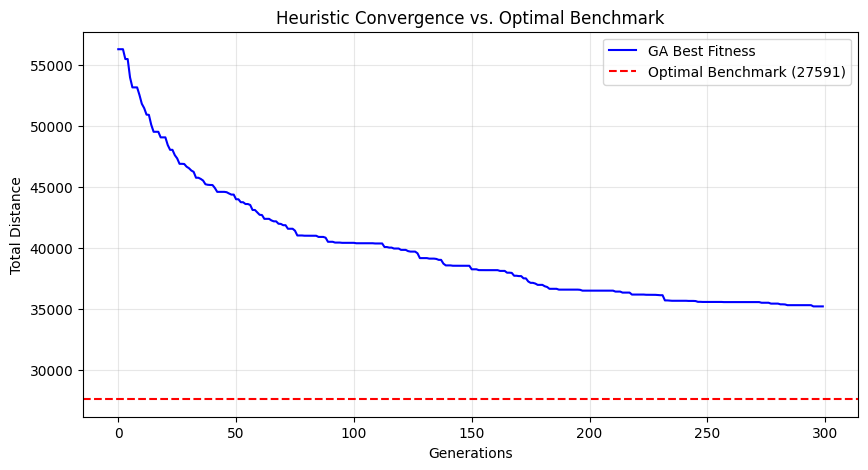

C:\Users\DELL\AppData\Local\Temp\ipykernel_23088\1193449948.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Method", y="Distance", data=df_comp, palette="viridis")


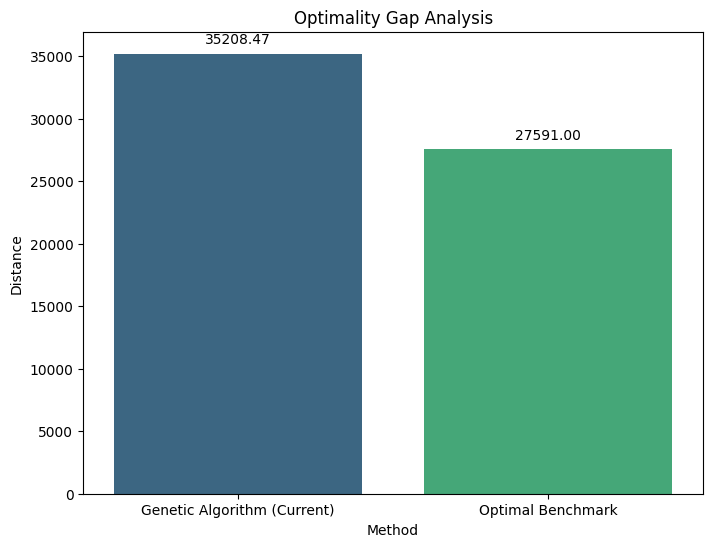

In [9]:
# GA Convergence Plot
plt.figure(figsize=(10, 5))
plt.plot(ga_history, color='blue', label='GA Best Fitness')
plt.axhline(y=27591, color='red', linestyle='--', label='Optimal Benchmark (27591)')
plt.title("Heuristic Convergence vs. Optimal Benchmark")
plt.xlabel("Generations")
plt.ylabel("Total Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Benchmarking Analysis
comp_data = {
    "Method": ["Genetic Algorithm (Current)", "Optimal Benchmark"],
    "Distance": [ga_res, 27591]
}
df_comp = pd.DataFrame(comp_data)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x="Method", y="Distance", data=df_comp, palette="viridis")
plt.title("Optimality Gap Analysis")
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()